In [166]:
from jitcdde import t
from toyParameters import *
import numpy as np
import matplotlib.pyplot as plt
from msrDynamics import Node, System

plt.rc("xtick", labelsize=16, top=True, direction="in")
plt.rc("ytick", labelsize=16, right=True, direction="in")
plt.rc("axes", titlesize=26)
plt.rc("axes", labelsize=16)
plt.rc("legend", fontsize=18)

Instantiate System Object & Nodes

In [167]:
# MSR system        
MSR = System()

# Datalab 8 data
rho_0 = 0.001
C0 = [172.8, 466.7, 114.3, 85.2, 6.58, 0.91]
Lam = 1e-4

# ODE system nodes
n = Node(y0 = n_frac0)     # fractional neutron density
C1 = Node(y0 = C0[0])      # precursor group 1
C2 = Node(y0 = C0[1])      # precursor group 2
C3 = Node(y0 = C0[2])      # precursor group 3
C4 = Node(y0 = C0[3])      # precursor group 4
C5 = Node(y0 = C0[4])      # precursor group 5
C6 = Node(y0 = C0[5])      # precursor group 6
rho = Node(y0 = rho_0)       # reactivity

# populate system 
MSR.add_nodes([n,C1,C2,C3,C4,C5,C6,rho])

Define Dynamics

In [168]:
T = np.arange(0, 50, 0.01)

tau_inf = 99999999.9

# ODE system itself
n.set_dndt(rho.y(), beta_t, Lam, lam, [C1.y(), C2.y(), C3.y(), C4.y(), C5.y(), C6.y()])
C1.set_dcdt(n.y(), beta[0], Lam, lam[0], True, tau_inf, tau_inf)
C2.set_dcdt(n.y(), beta[1], Lam, lam[1], True, tau_inf, tau_inf)
C3.set_dcdt(n.y(), beta[2], Lam, lam[2], True, tau_inf, tau_inf)
C4.set_dcdt(n.y(), beta[3], Lam, lam[3], True, tau_inf, tau_inf)
C5.set_dcdt(n.y(), beta[4], Lam, lam[4], True, tau_inf, tau_inf)
C6.set_dcdt(n.y(), beta[5], Lam, lam[5], True, tau_inf, tau_inf)

sol_jit = MSR.solve(T)

n_no_delay = n.y_out

Generating, compiling, and loading C code.
Using default integration parameters.


In [169]:
tau_c = 6
tau_l = 2

n.set_dndt(rho.y(), beta_t, Lam, lam, [C1.y(), C2.y(), C3.y(), C4.y(), C5.y(), C6.y()])
C1.set_dcdt(n.y(), beta[0], Lam, lam[0], True, tau_c, tau_l)
C2.set_dcdt(n.y(), beta[1], Lam, lam[1], True, tau_c, tau_l)
C3.set_dcdt(n.y(), beta[2], Lam, lam[2], True, tau_c, tau_l)
C4.set_dcdt(n.y(), beta[3], Lam, lam[3], True, tau_c, tau_l)
C5.set_dcdt(n.y(), beta[4], Lam, lam[4], True, tau_c, tau_l)
C6.set_dcdt(n.y(), beta[5], Lam, lam[5], True, tau_c, tau_l)

sol_jit = MSR.solve(T)

n_delay = n.y_out

Generating, compiling, and loading C code.


Using default integration parameters.


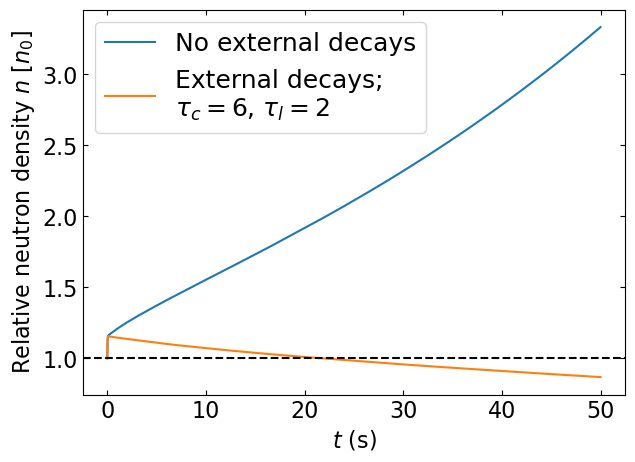

In [185]:
fig, ax = plt.subplots(figsize=(7, 5))

t0 = -5.0
tf = 50.0

ax.plot(T, n_no_delay, label='No external decays')
ax.plot(T, n_delay, label='External decays; \n' + rf'$\tau_c={tau_c}$, $\tau_l={tau_l}$')
# ax.set_xlim(t0, tf)
ax.set_xlabel(r"$t$ (s)")
ax.set_ylabel(r'Relative neutron density $n$ [$n_0$]')
# ax.set_title('Relative neutron densities')
ax.axhline(n_frac0, c='k', ls='--')
ax.legend()

plt.savefig('no_geometry_comparison.png')